In [32]:
!git clone https://github.com/UCT-Advanced-Image-Analysis/semester-project-2026.git

fatal: destination path 'semester-project-2026' already exists and is not an empty directory.


In [33]:
# The only extra install you might need
!pip install pingouin -q

In [34]:


import pandas as pd
import pingouin as pg
from sklearn.metrics import cohen_kappa_score

In [35]:
import glob
import os

search_path = '/content/semester-project-2026/images'
pattern = os.path.join(search_path, '**', 'student_*.csv')

found_files = glob.glob(pattern, recursive=True)

if found_files:
    print("Found 'student_*.csv' files:")
    for file_path in found_files:
        print(file_path)
else:
    print("No 'student_*.csv' files found in the specified path.")

Found 'student_*.csv' files:
/content/semester-project-2026/images/student_10/student_10_counts.csv
/content/semester-project-2026/images/student_03/student_03_counts.csv
/content/semester-project-2026/images/student_04/student_04_counts.csv
/content/semester-project-2026/images/student_06/student_06_counts.csv
/content/semester-project-2026/images/student_07/student_07_counts.csv
/content/semester-project-2026/images/student_09/student_09_counts.csv
/content/semester-project-2026/images/student_08/student_08_counts.csv
/content/semester-project-2026/images/student_05/student_05_counts.csv
/content/semester-project-2026/images/student_02/student_02_counts.csv


Load CSV

In [36]:
import pandas as pd
import re
import os

data = []
for file_path in found_files:
    filename = os.path.basename(file_path)
    match = re.search(r'student_(\d+)_counts\.csv', filename)
    if match:
        student_number = match.group(1)
        data.append({'student_number': student_number, 'path': file_path})

student_df = pd.DataFrame(data)
display(student_df.head())

,student_number,path
0,10,/content/semester-project-2026/images/student_...
1,03,/content/semester-project-2026/images/student_...
2,04,/content/semester-project-2026/images/student_...
3,06,/content/semester-project-2026/images/student_...
4,07,/content/semester-project-2026/images/student_...


Load file mapping from blind file mixing

In [37]:
url = 'https://github.com/UCT-Advanced-Image-Analysis/semester-project-2026-eval/raw/refs/heads/main/tables/image_mapping_v2.csv'
image_mapping_df = pd.read_csv(url)
display(image_mapping_df.head())

,original_path,student_folder,new_filename,image_type
0,/content/gdrive/MyDrive/+Projects/01_Python/02...,student_01,img_5.tif,calibration
1,/content/gdrive/MyDrive/+Projects/01_Python/02...,student_01,img_13.tif,calibration
2,/content/gdrive/MyDrive/+Projects/01_Python/02...,student_01,img_14.tif,calibration
3,/content/gdrive/MyDrive/+Projects/01_Python/02...,student_01,img_8.tif,calibration
4,/content/gdrive/MyDrive/+Projects/01_Python/02...,student_01,img_11.tif,duplicate


In [38]:
image_mapping_df['original_filename'] = image_mapping_df['original_path'].apply(lambda x: x.split('/')[-1].replace('.tif', ''))
display(image_mapping_df.head())

,original_path,student_folder,new_filename,image_type,original_filename
0,/content/gdrive/MyDrive/+Projects/01_Python/02...,student_01,img_5.tif,calibration,9GRAY_015-cropped
1,/content/gdrive/MyDrive/+Projects/01_Python/02...,student_01,img_13.tif,calibration,16GRAY_045-cropped
2,/content/gdrive/MyDrive/+Projects/01_Python/02...,student_01,img_14.tif,calibration,4GRAY_000-cropped
3,/content/gdrive/MyDrive/+Projects/01_Python/02...,student_01,img_8.tif,calibration,1GRAY_030-cropped
4,/content/gdrive/MyDrive/+Projects/01_Python/02...,student_01,img_11.tif,duplicate,12GRAY_015-cropped


Load numbers from correct images

In [39]:
student_dataframes = {}

for index, row in student_df.iterrows():
    student_number = row['student_number']
    file_path = row['path']

    # Load the CSV file, using ';' as a separator
    df_student = pd.read_csv(file_path, sep=';', header=0, index_col=None, encoding='utf-8')

    # Add the 'student_folder' column
    df_student['student_folder'] = 'student_' + student_number

    # Store the DataFrame in the dictionary
    student_dataframes[student_number] = df_student


print(f"Loaded data for {len(student_dataframes)} students.")

# Display the head of one of the student dataframes as an example
if student_dataframes:
    first_student_key = list(student_dataframes.keys())[0]
    print(f"\nDisplaying head for student {first_student_key}:")
    display(student_dataframes[first_student_key].head())

Loaded data for 9 students.

Displaying head for student 10:


,image_name,manual_count,script_own,script_simple,script_watershed 1,script_own_sparse,script_SarDist,YOLO_count,student_folder
0,img_01,60,54,47,58,58,64,NaN,student_10
1,img_02,77,59,57,80,80,83,NaN,student_10
2,img_03,54,37,28,49,49,56,NaN,student_10
3,img_04,42,38,34,42,42,45,NaN,student_10
4,img_05,73,49,45,52,52,73,NaN,student_10


In [40]:
import re

for student_number, df_student in student_dataframes.items():
    # Standardize image_name to match the format in image_mapping_df (e.g., 'img_1.tif' instead of 'img_01.tif')
    # First, ensure it's a string and remove any existing '.tif' for consistent processing
    df_student['image_name'] = df_student['image_name'].astype(str).str.replace('\.tif$', '', regex=True)
    # Then, remove leading zeros from the numeric part of the image name
    df_student['image_name'] = df_student['image_name'].apply(lambda x: re.sub(r'img_0*(\d+)$', r'img_\1', x)) + '.tif'
    student_dataframes[student_number] = df_student

print("Standardized 'image_name' column formatting in all student dataframes.")

# Display the head of one of the updated student dataframes as an example
if student_dataframes:
    first_student_key = list(student_dataframes.keys())[0]
    print(f"\nDisplaying head for standardized student {first_student_key}:")
    display(student_dataframes[first_student_key].head())

Standardized 'image_name' column formatting in all student dataframes.

Displaying head for standardized student 10:


<>:6: SyntaxWarning: invalid escape sequence '\.'
<>:6: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_3295/2773219164.py:6: SyntaxWarning: invalid escape sequence '\.'
  df_student['image_name'] = df_student['image_name'].astype(str).str.replace('\.tif$', '', regex=True)


,image_name,manual_count,script_own,script_simple,script_watershed 1,script_own_sparse,script_SarDist,YOLO_count,student_folder
0,img_1.tif,60,54,47,58,58,64,NaN,student_10
1,img_2.tif,77,59,57,80,80,83,NaN,student_10
2,img_3.tif,54,37,28,49,49,56,NaN,student_10
3,img_4.tif,42,38,34,42,42,45,NaN,student_10
4,img_5.tif,73,49,45,52,52,73,NaN,student_10


In [41]:
# Ensure image_mapping_df['new_filename'] is string type once before the loop
image_mapping_df['new_filename'] = image_mapping_df['new_filename'].astype(str)

for student_number, df_student in student_dataframes.items():
    # Ensure df_student['image_name'] is string type immediately before merge for each student's DataFrame
    df_student['image_name'] = df_student['image_name'].astype(str)

    # Merge with image_mapping_df using 'student_folder' and 'image_name' (from df_student)
    # and 'new_filename' (from image_mapping_df)
    merged_df = pd.merge(
        df_student,
        image_mapping_df[['student_folder', 'new_filename', 'image_type', 'original_filename']],
        left_on=['student_folder', 'image_name'],
        right_on=['student_folder', 'new_filename'],
        how='left'
    )
    # Drop the redundant 'new_filename' column from the merge if it exists
    # Note: 'new_filename' is from image_mapping_df, which we don't want to keep in the final student_df
    merged_df = merged_df.drop(columns=['new_filename'])
    student_dataframes[student_number] = merged_df

print("Updated student_dataframes with image_type and original_filename.")

# Display the head of one of the updated student dataframes as an example
if student_dataframes:
    first_student_key = list(student_dataframes.keys())[0]
    print(f"\nDisplaying head for updated student {first_student_key}:")
    display(student_dataframes[first_student_key].head())

Updated student_dataframes with image_type and original_filename.

Displaying head for updated student 10:


,image_name,manual_count,script_own,script_simple,script_watershed 1,script_own_sparse,script_SarDist,YOLO_count,student_folder,image_type,original_filename
0,img_1.tif,60,54,47,58,58,64,NaN,student_10,unique_random,19GRAY_015-cropped
1,img_2.tif,77,59,57,80,80,83,NaN,student_10,unique_random,14GRAY_000-cropped
2,img_3.tif,54,37,28,49,49,56,NaN,student_10,unique_random,18GRAY_030-cropped
3,img_4.tif,42,38,34,42,42,45,NaN,student_10,unique_random,11GRAY_030-cropped
4,img_5.tif,73,49,45,52,52,73,NaN,student_10,unique_random,10GRAY_030-cropped


In [42]:
df_student = student_dataframes[first_student_key]
df_student[df_student['image_type']=='calibration']

,image_name,manual_count,script_own,script_simple,script_watershed 1,script_own_sparse,script_SarDist,YOLO_count,student_folder,image_type,original_filename
5,img_6.tif,72,50,48,58,58,71,NaN,student_10,calibration,9GRAY_015-cropped
6,img_7.tif,55,42,37,46,46,55,NaN,student_10,calibration,1GRAY_030-cropped
8,img_9.tif,70,64,60,73,73,75,NaN,student_10,calibration,4GRAY_000-cropped
12,img_13.tif,58,35,33,43,43,51,NaN,student_10,calibration,16GRAY_045-cropped


In [43]:
import pandas as pd

# Concatenate all student dataframes into one big table
all_students_df = pd.concat(student_dataframes.values(), ignore_index=True)

# Handle potential duplicate columns from merge (image_type, original_filename)
# The image_mapping_df was the right-hand side of the merge, so its columns get _y suffix.
# These are the correct columns to keep.
if 'image_type_y' in all_students_df.columns:
    all_students_df['image_type'] = all_students_df['image_type_y']
    all_students_df = all_students_df.drop(columns=['image_type_y'])
if 'original_filename_y' in all_students_df.columns:
    all_students_df['original_filename'] = all_students_df['original_filename_y']
    all_students_df = all_students_df.drop(columns=['original_filename_y'])

# Drop _x versions if they exist (they shouldn't contain relevant data from original df_student)
if 'image_type_x' in all_students_df.columns:
    all_students_df = all_students_df.drop(columns=['image_type_x'])
if 'original_filename_x' in all_students_df.columns:
    all_students_df = all_students_df.drop(columns=['original_filename_x'])


# Add a new column 'student' as a duplicate of 'student_folder'
all_students_df['student'] = all_students_df['student_folder']

# Extract 'xx' from 'student_folder'
xx = all_students_df['student_folder'].str.extract(r'student_(\d+)').iloc[:, 0]

# Extract 'yy' from 'image_name' (image_name should now be standardized to 'img_X.tif')
yy = all_students_df['image_name'].str.extract(r'img_(\d+)\.tif').iloc[:, 0]

# Create the new 'path' column
all_students_df['path'] = 'student_' + xx + '/img_' + yy + '.tiff'

# Display the head of the new big table
display(all_students_df.head())

,image_name,manual_count,script_own,script_simple,script_watershed 1,script_own_sparse,script_SarDist,YOLO_count,student_folder,image_type,original_filename,script_watershed,student,path
0,img_1.tif,60.0,54.0,47.0,58.0,58.0,64.0,NaN,student_10,unique_random,19GRAY_015-cropped,NaN,student_10,student_10/img_1.tiff
1,img_2.tif,77.0,59.0,57.0,80.0,80.0,83.0,NaN,student_10,unique_random,14GRAY_000-cropped,NaN,student_10,student_10/img_2.tiff
2,img_3.tif,54.0,37.0,28.0,49.0,49.0,56.0,NaN,student_10,unique_random,18GRAY_030-cropped,NaN,student_10,student_10/img_3.tiff
3,img_4.tif,42.0,38.0,34.0,42.0,42.0,45.0,NaN,student_10,unique_random,11GRAY_030-cropped,NaN,student_10,student_10/img_4.tiff
4,img_5.tif,73.0,49.0,45.0,52.0,52.0,73.0,NaN,student_10,unique_random,10GRAY_030-cropped,NaN,student_10,student_10/img_5.tiff


In [44]:
all_students_df.to_csv('all_students_df.csv', index=False)

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Filter for duplicate images
duplicates_df = all_students_df[all_students_df['image_type'] == 'duplicate'].copy()

duplicates_df

,image_name,manual_count,script_own,script_simple,script_watershed 1,script_own_sparse,script_SarDist,YOLO_count,student_folder,image_type,original_filename,script_watershed,student,path
7,img_8.tif,81.0,70.0,71.0,82.0,82.0,83.0,NaN,student_10,duplicate,12GRAY_000-cropped,NaN,student_10,student_10/img_8.tiff
14,img_15.tif,80.0,70.0,71.0,82.0,82.0,83.0,NaN,student_10,duplicate,12GRAY_000-cropped,NaN,student_10,student_10/img_15.tiff
23,img_9.tif,55.0,35.0,45.0,NaN,51.0,NaN,NaN,student_03,duplicate,19GRAY_030-cropped,53.0,student_03,student_03/img_9.tiff
29,img_15.tif,55.0,35.0,45.0,NaN,51.0,NaN,NaN,student_03,duplicate,19GRAY_030-cropped,53.0,student_03,student_03/img_15.tiff
31,img_2.tif,69.0,45.0,46.0,NaN,59.0,63.0,NaN,student_04,duplicate,12GRAY_015-cropped,61.0,student_04,student_04/img_2.tiff
39,img_10.tif,77.0,50.0,52.0,NaN,67.0,63.0,NaN,student_04,duplicate,12GRAY_015-cropped,68.0,student_04,student_04/img_10.tiff
66,img_7.tif,114.0,54.0,44.0,NaN,61.0,95.0,NaN,student_07,duplicate,11GRAY_045-cropped,97.0,student_07,student_07/img_7.tiff
69,img_10.tif,109.0,51.0,44.0,NaN,61.0,95.0,NaN,student_07,duplicate,11GRAY_045-cropped,97.0,student_07,student_07/img_10.tiff
76,img_2.tif,79.0,41.0,42.0,NaN,60.0,73.0,NaN,student_09,duplicate,15GRAY_030-cropped,74.0,student_09,student_09/img_2.tiff
78,img_4.tif,79.0,41.0,42.0,NaN,60.0,73.0,NaN,student_09,duplicate,15GRAY_030-cropped,74.0,student_09,student_09/img_4.tiff


In [46]:
import pandas as pd
import numpy as np
from PIL import Image
import os
from scipy.optimize import linear_sum_assignment # Added for instance-level matching

# --- Helper Functions ---# Modified to load array directly, preserving object IDs
def load_mask_as_array(mask_path, target_size=None):
    """
    Loads a mask image, converts to grayscale, and returns it as a numpy array
    preserving intensity values (object IDs). Optionally resizes.
    Returns a numpy array and its original size, or (None, None) if loading fails.
    """
    if not os.path.exists(mask_path):
        # print(f"Mask file not found: {mask_path}") # Uncomment for debugging missing files
        return None, None
    try:
        mask_img = Image.open(mask_path).convert('L') # Ensure grayscale, preserving intensity
        original_size = mask_img.size
        if target_size and mask_img.size != target_size:
            mask_img = mask_img.resize(target_size, Image.NEAREST)
        # Return as integer array directly, assuming pixel values are object IDs or 0 for background
        return np.array(mask_img), original_size
    except Exception as e:
        print(f"Error loading mask {mask_path}: {e}")
        return None, None

def calculate_instance_metrics(pred_labels, gt_labels, iou_threshold=0.5):
    """
    Calculates instance-level metrics (Precision, Recall, F1-score) and mean IoU.
    Assumes pred_labels and gt_labels are integer numpy arrays where unique non-zero
    values represent object instances.

    **Instance-level Evaluation Explained:**
    This function focuses on individual object instances rather than treating all foreground pixels as a single class. This is crucial for tasks where distinguishing separate objects is important. Here's a breakdown of the process:
    1.  **Object Identification**: The function first identifies all unique non-zero pixel values in both the predicted and ground truth label masks. Each unique non-zero value is considered an individual object instance.
    2.  **IoU Matrix Calculation**: For every possible pair of predicted object and ground truth object, an Intersection over Union (IoU) score is calculated. This creates an an IoU matrix where rows correspond to predicted instances and columns correspond to ground truth instances.
    3.  **Bipartite Matching (Hungarian Algorithm)**: To establish a one-to-one correspondence between predicted and ground truth objects, the Hungarian algorithm (specifically, `scipy.optimize.linear_sum_assignment`) is used. This algorithm finds the optimal matching that maximizes the sum of IoU scores between matched pairs. It essentially decides which predicted object best corresponds to which ground truth object.
    4.  **Thresholding and Classification**: A predefined `iou_threshold` (defaulting to 0.5) is applied. A matched pair is considered a True Positive (TP) if their IoU score is greater than or equal to this threshold. If a predicted object is matched but its IoU with the ground truth object is below the threshold, or if a predicted object cannot be matched to any ground truth object, it's considered a False Positive (FP). If a ground truth object cannot be matched to any predicted object, it's considered a False Negative (FN).
    5.  **Metric Calculation**: Based on these TP, FP, and FN counts for instances, the following metrics are calculated:
        *   **Precision_instance**: `TP / (TP + FP)` - The proportion of correctly detected instances among all detected instances.
        *   **Recall_instance**: `TP / (TP + FN)` - The proportion of detected instances among all actual instances.
        *   **F1_instance**: The harmonic mean of Precision and Recall, providing a single score that balances both.
        *   **IoU_instance_mean**: The average IoU score of all correctly matched (True Positive) instances.
    """
    if pred_labels.shape != gt_labels.shape:
        raise ValueError("Prediction and Ground Truth masks must have the same shape.")

    pred_ids = np.unique(pred_labels[pred_labels > 0])
    gt_ids = np.unique(gt_labels[gt_labels > 0])

    num_pred = len(pred_ids)
    num_gt = len(gt_ids)

    if num_pred == 0 and num_gt == 0:
        return {'IoU_instance_mean': 1.0, 'Precision_instance': 1.0, 'Recall_instance': 1.0, 'F1_instance': 1.0, 'TP_instance': 0, 'FP_instance': 0, 'FN_instance': 0}
    if num_pred == 0: # Only GT objects, all are false negatives
        return {'IoU_instance_mean': 0.0, 'Precision_instance': 0.0, 'Recall_instance': 0.0, 'F1_instance': 0.0, 'TP_instance': 0, 'FP_instance': 0, 'FN_instance': num_gt}
    if num_gt == 0: # Only Pred objects, all are false positives
        return {'IoU_instance_mean': 0.0, 'Precision_instance': 0.0, 'Recall_instance': 0.0, 'F1_instance': 0.0, 'TP_instance': 0, 'FP_instance': num_pred, 'FN_instance': 0}

    # IoU matrix for all pairs of predicted and ground truth instances
    iou_matrix = np.zeros((num_pred, num_gt))

    for i, p_id in enumerate(pred_ids):
        p_mask = (pred_labels == p_id)
        for j, g_id in enumerate(gt_ids):
            g_mask = (gt_labels == g_id)

            intersection = np.sum(np.logical_and(p_mask, g_mask))
            union = np.sum(np.logical_or(p_mask, g_mask))
            iou_matrix[i, j] = intersection / union if union > 0 else 0.0

    # Optimal bipartite matching using Hungarian algorithm
    # Cost matrix is 1 - IoU (we want to maximize IoU, so minimize 1-IoU)
    # Rows correspond to predicted instances, columns to ground truth instances
    row_ind, col_ind = linear_sum_assignment(1 - iou_matrix)

    matched_iou_scores = []
    tp_instance = 0
    fp_instance = 0
    fn_instance = 0

    # Determine True Positives, False Positives, False Negatives
    matched_gt = set()
    for p_idx, g_idx in zip(row_ind, col_ind):
        if iou_matrix[p_idx, g_idx] >= iou_threshold:
            tp_instance += 1
            matched_iou_scores.append(iou_matrix[p_idx, g_idx])
            matched_gt.add(gt_ids[g_idx]) # Keep track of matched GT instances

    fp_instance = num_pred - tp_instance # Predicted instances not matched above threshold
    fn_instance = num_gt - len(matched_gt) # GT instances not matched

    # Calculate mean IoU for matched instances
    iou_instance_mean = np.mean(matched_iou_scores) if matched_iou_scores else 0.0

    # Calculate Precision, Recall, F1-score
    precision_instance = tp_instance / (tp_instance + fp_instance) if (tp_instance + fp_instance) > 0 else 0.0
    recall_instance = tp_instance / (tp_instance + fn_instance) if (tp_instance + fn_instance) > 0 else 0.0
    f1_instance = 2 * (precision_instance * recall_instance) / (precision_instance + recall_instance) if (precision_instance + recall_instance) > 0 else 0.0

    return {
        'IoU_instance_mean': iou_instance_mean,
        'Precision_instance': precision_instance,
        'Recall_instance': recall_instance,
        'F1_instance': f1_instance,
        'TP_instance': tp_instance,
        'FP_instance': fp_instance,
        'FN_instance': fn_instance
    }

# --- Prepare duplicates_df with necessary path columns and student_id ---

# Ensure base_repo_path is available
if 'base_repo_path' not in locals():
    base_repo_path = '/content/semester-project-2026/'

# Add 'student_id' column to duplicates_df for easier grouping
if 'student_id' not in duplicates_df.columns:
    duplicates_df['student_id'] = duplicates_df['student_folder'].str.replace('student_', '')

# Ensure duplicates_df has the necessary full path columns (if not already derived)
# The 'label_map_full_path' is for student's own submission
if 'label_map_full_path' not in duplicates_df.columns:
    duplicates_df['label_map_full_path'] = duplicates_df['path'].astype(str).apply(
        lambda x: os.path.join(base_repo_path, 'labels', x).replace('.tiff', '.tif')
    )

# MODIFICATION: Add 'pseudo_gt_mask_full_path' using the specified structure for the new GT source
if 'pseudo_gt_mask_full_path' not in duplicates_df.columns:
    duplicates_df['pseudo_gt_mask_full_path'] = duplicates_df.apply(
        lambda row: os.path.join(base_repo_path, 'labels', 'GT', row['student_folder'], row['image_name']),
        axis=1
    )
    print("Added 'pseudo_gt_mask_full_path' to duplicates_df for new GT source.")


# --- Comparison 1: Duplicate masks against each other for each student ---
print("\n--- Starting Duplicate Self-Comparison (Student Masks against each other) ---")
duplicate_self_comparison_results = []

grouped_duplicates_for_self_comp = duplicates_df.groupby(['student_id', 'original_filename'])

for (student_id, original_filename), group in grouped_duplicates_for_self_comp:
    label_map_paths = group['label_map_full_path'].tolist()

    if len(label_map_paths) > 1: # Only compare if there are actual duplicate submissions for this student/image
        loaded_label_info = [] # Changed to store labels
        # Attempt to load the first mask to establish a target size
        first_labels, first_size = load_mask_as_array(label_map_paths[0]) # Use new loading function
        if first_labels is None:
            print(f"Could not load first mask for student {student_id}, original {original_filename}. Skipping group.")
            continue
        loaded_label_info.append({'path': label_map_paths[0], 'labels': first_labels})
        target_size = first_size

        # Load remaining masks, resizing to the target_size
        for path in label_map_paths[1:]:
            labels, _ = load_mask_as_array(path, target_size=target_size) # Use new loading function
            if labels is not None:
                loaded_label_info.append({'path': path, 'labels': labels})
            else:
                print(f"Warning: Could not load or resize mask {path} for student {student_id}, original {original_filename}.")

        if len(loaded_label_info) < 2:
            print(f"Not enough valid masks for self-comparison for student {student_id}, original {original_filename}. Skipping.")
            continue

        # Perform pairwise comparison
        for i in range(len(loaded_label_info)):
            for j in range(i + 1, len(loaded_label_info)):
                labels1 = loaded_label_info[i]['labels']
                labels2 = loaded_label_info[j]['labels']

                # Calculate instance metrics
                instance_metrics = calculate_instance_metrics(labels1, labels2)

                duplicate_self_comparison_results.append({
                    'student_id': student_id,
                    'original_filename': original_filename,
                    'comparison_type': 'student_duplicate_self',
                    'mask_path_1': loaded_label_info[i]['path'],
                    'mask_path_2': loaded_label_info[j]['path'],
                    **instance_metrics
                })

duplicate_self_comparison_df = pd.DataFrame(duplicate_self_comparison_results)

if not duplicate_self_comparison_df.empty:
    print("\nDuplicate Self-Comparison Results:")
    display(duplicate_self_comparison_df.head())
    print("\nSummary Statistics for Duplicate Self-Comparison (Instance):")
    display(duplicate_self_comparison_df[['IoU_instance_mean', 'Precision_instance', 'Recall_instance', 'F1_instance']].describe())
else:
    print("\nNo duplicate self-comparison results could be generated.")


# --- Comparison 2: Duplicate masks against pseudo ground truth mask for each student ---
print("\n--- Starting Duplicate vs. Pseudo Ground Truth Comparison (Each Student Mask) ---")
duplicate_pseudo_gt_comparison_results = [] # Renamed variable

for index, row in duplicates_df.iterrows():
    student_mask_path = row['label_map_full_path']
    # MODIFICATION: Use pseudo_gt_mask_full_path
    pseudo_gt_mask_path = row['pseudo_gt_mask_full_path']
    original_filename = row['original_filename']
    student_id = row['student_id']

    # MODIFICATION: Load pseudo_gt_mask as labels
    pseudo_gt_labels, pseudo_gt_size = load_mask_as_array(pseudo_gt_mask_path)
    if pseudo_gt_labels is None:
        # print(f"Pseudo GT mask not found or failed to load for {original_filename} (student {student_id}). Skipping.")
        continue

    student_labels, _ = load_mask_as_array(student_mask_path, target_size=pseudo_gt_size) # Resize student mask to Pseudo GT size
    if student_labels is None:
        # print(f"Student mask not found or failed to load for {original_filename} (student {student_id}). Skipping.")
        continue

    # Calculate instance metrics
    instance_metrics = calculate_instance_metrics(student_labels, pseudo_gt_labels)

    duplicate_pseudo_gt_comparison_results.append({ # Renamed variable
        'student_id': student_id,
        'original_filename': original_filename,
        'comparison_type': 'student_duplicate_vs_pseudo_gt', # Renamed type
        'student_mask_path': student_mask_path,
        **instance_metrics
    })

duplicate_pseudo_gt_comparison_df = pd.DataFrame(duplicate_pseudo_gt_comparison_results) # Renamed variable

# Add a column to differentiate between multiple duplicate submissions for the same image by the same student
# This part remains the same logic as it applies to the new comparison results DataFrame
if not duplicate_pseudo_gt_comparison_df.empty:
    duplicate_pseudo_gt_comparison_df['duplicate_submission_idx'] = duplicate_pseudo_gt_comparison_df.groupby(['student_id', 'original_filename']).cumcount() + 1

if not duplicate_pseudo_gt_comparison_df.empty:
    print("\nDuplicate vs. Pseudo Ground Truth Comparison Results:")
    display(duplicate_pseudo_gt_comparison_df.head())
    print("\nSummary Statistics for Duplicate vs. Pseudo Ground Truth Comparison (Instance):")
    display(duplicate_pseudo_gt_comparison_df[['IoU_instance_mean', 'Precision_instance', 'Recall_instance', 'F1_instance']].describe())
else:
    print("\nNo duplicate vs. pseudo ground truth comparison results generated.")

Added 'pseudo_gt_mask_full_path' to duplicates_df for new GT source.

--- Starting Duplicate Self-Comparison (Student Masks against each other) ---
Could not load first mask for student 03, original 19GRAY_030-cropped. Skipping group.
Could not load first mask for student 04, original 12GRAY_015-cropped. Skipping group.
Could not load first mask for student 08, original 10GRAY_015-cropped. Skipping group.
Could not load first mask for student 10, original 12GRAY_000-cropped. Skipping group.

Duplicate Self-Comparison Results:


,student_id,original_filename,comparison_type,mask_path_1,mask_path_2,IoU_instance_mean,Precision_instance,Recall_instance,F1_instance,TP_instance,FP_instance,FN_instance
0,02,12GRAY_015-cropped,student_duplicate_self,/content/semester-project-2026/labels/student_...,/content/semester-project-2026/labels/student_...,0.791382,0.764706,0.764706,0.764706,52,16,16
1,05,17GRAY_030-cropped,student_duplicate_self,/content/semester-project-2026/labels/student_...,/content/semester-project-2026/labels/student_...,0.784829,0.506173,0.506173,0.506173,41,40,40
2,07,11GRAY_045-cropped,student_duplicate_self,/content/semester-project-2026/labels/student_...,/content/semester-project-2026/labels/student_...,0.682589,0.407407,0.379310,0.392857,33,48,54
3,09,15GRAY_030-cropped,student_duplicate_self,/content/semester-project-2026/labels/student_...,/content/semester-project-2026/labels/student_...,0.778267,0.728571,0.728571,0.728571,51,19,19



Summary Statistics for Duplicate Self-Comparison (Instance):


,IoU_instance_mean,Precision_instance,Recall_instance,F1_instance
count,4.000000,4.000000,4.000000,4.000000
mean,0.759267,0.601714,0.594690,0.598077
std,0.051398,0.172764,0.183533,0.178284
min,0.682589,0.407407,0.379310,0.392857
25%,0.754347,0.481481,0.474457,0.477844
50%,0.781548,0.617372,0.617372,0.617372
75%,0.786468,0.737605,0.737605,0.737605
max,0.791382,0.764706,0.764706,0.764706



--- Starting Duplicate vs. Pseudo Ground Truth Comparison (Each Student Mask) ---

Duplicate vs. Pseudo Ground Truth Comparison Results:


,student_id,original_filename,comparison_type,student_mask_path,IoU_instance_mean,Precision_instance,Recall_instance,F1_instance,TP_instance,FP_instance,FN_instance,duplicate_submission_idx
0,07,11GRAY_045-cropped,student_duplicate_vs_pseudo_gt,/content/semester-project-2026/labels/student_...,0.629633,0.382716,0.392405,0.387500,31,50,48,1
1,07,11GRAY_045-cropped,student_duplicate_vs_pseudo_gt,/content/semester-project-2026/labels/student_...,0.698320,0.344828,0.379747,0.361446,30,57,49,2
2,09,15GRAY_030-cropped,student_duplicate_vs_pseudo_gt,/content/semester-project-2026/labels/student_...,0.803467,0.714286,0.746269,0.729927,50,20,17,1
3,09,15GRAY_030-cropped,student_duplicate_vs_pseudo_gt,/content/semester-project-2026/labels/student_...,0.802057,0.657143,0.686567,0.671533,46,24,21,2
4,05,17GRAY_030-cropped,student_duplicate_vs_pseudo_gt,/content/semester-project-2026/labels/student_...,0.753340,0.493827,0.526316,0.509554,40,41,36,1



Summary Statistics for Duplicate vs. Pseudo Ground Truth Comparison (Instance):


,IoU_instance_mean,Precision_instance,Recall_instance,F1_instance
count,8.000000,8.000000,8.000000,8.000000
mean,0.715394,0.552223,0.584012,0.567633
std,0.074561,0.137634,0.142586,0.140059
min,0.622458,0.344828,0.379747,0.361446
25%,0.647288,0.466049,0.492838,0.479041
50%,0.725830,0.574256,0.611020,0.592067
75%,0.771045,0.661975,0.694613,0.677892
max,0.803467,0.714286,0.746269,0.729927



### Visualization: Duplicate Masks Against Each Other (Instance Metrics)



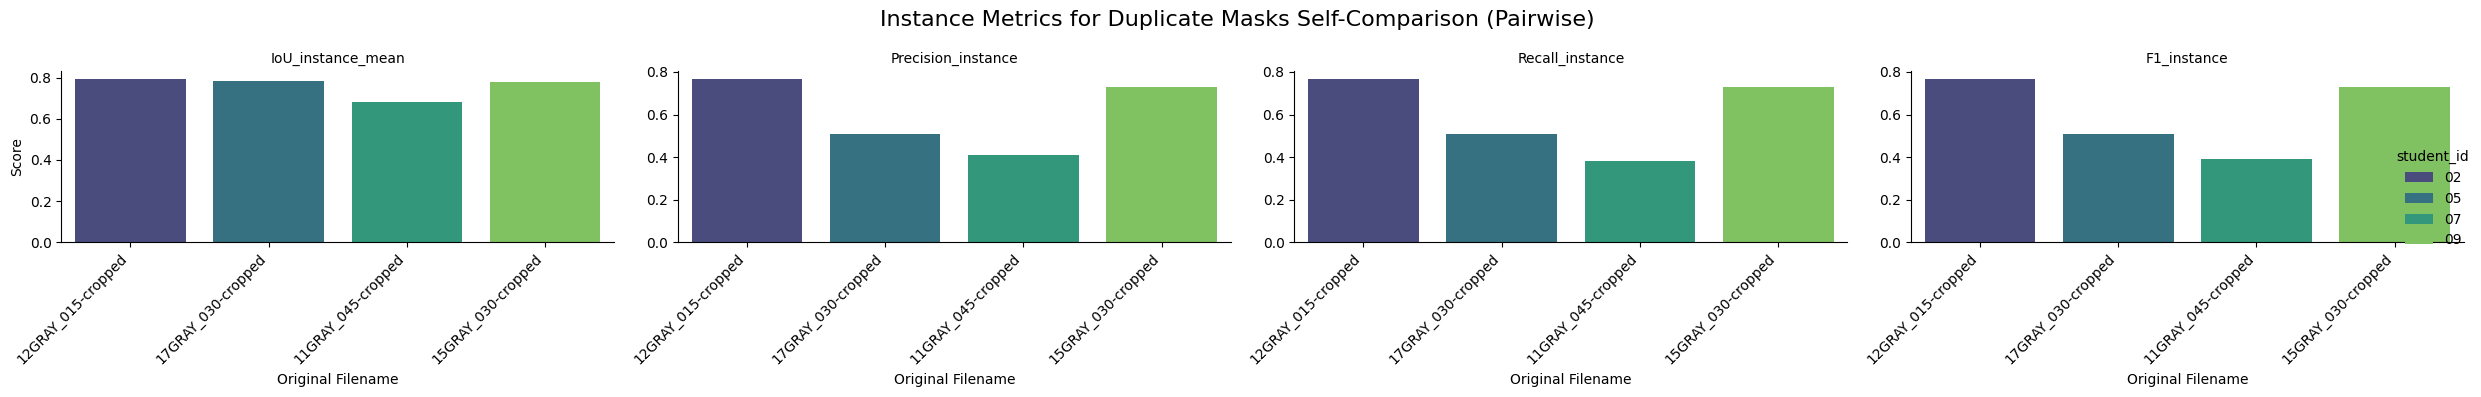

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Visualization 1: Duplicate masks against each other for each student (Instance Metrics) ---
if not duplicate_self_comparison_df.empty:
    print("\n### Visualization: Duplicate Masks Against Each Other (Instance Metrics)\n")
    metrics_to_plot_instance = ['IoU_instance_mean', 'Precision_instance', 'Recall_instance', 'F1_instance']
    melted_self_comp_df = duplicate_self_comparison_df.melt(
        id_vars=['student_id', 'original_filename'],
        value_vars=metrics_to_plot_instance,
        var_name='Metric',
        value_name='Score'
    )

    melted_self_comp_df.to_csv('duplicate_masks_self_comparison-instance.csv', index=False)

    g = sns.catplot(
        data=melted_self_comp_df,
        x='original_filename',
        y='Score',
        hue='student_id',
        col='Metric',
        kind='bar',
        col_wrap=4,
        height=4, aspect=1.5,
        palette='viridis',
        legend='auto',
        legend_out=True,
        errorbar=None,
        sharey=False
    )
    g.set_axis_labels("Original Filename", "Score")
    g.set_titles(col_template="{col_name}")
    g.set_xticklabels(rotation=45, ha='right')
    g.fig.suptitle('Instance Metrics for Duplicate Masks Self-Comparison (Pairwise)', y=0.98, fontsize=16)
    plt.tight_layout()
    plt.savefig('duplicate_masks_self_comparison-instance.png')
    plt.show()
else:
    print("\nNo data available for 'Duplicate Masks Against Each Other (Instance Metrics)' visualization.")


### Visualization: Individual Duplicate Masks vs. Pseudo Ground Truth (Instance Metrics)



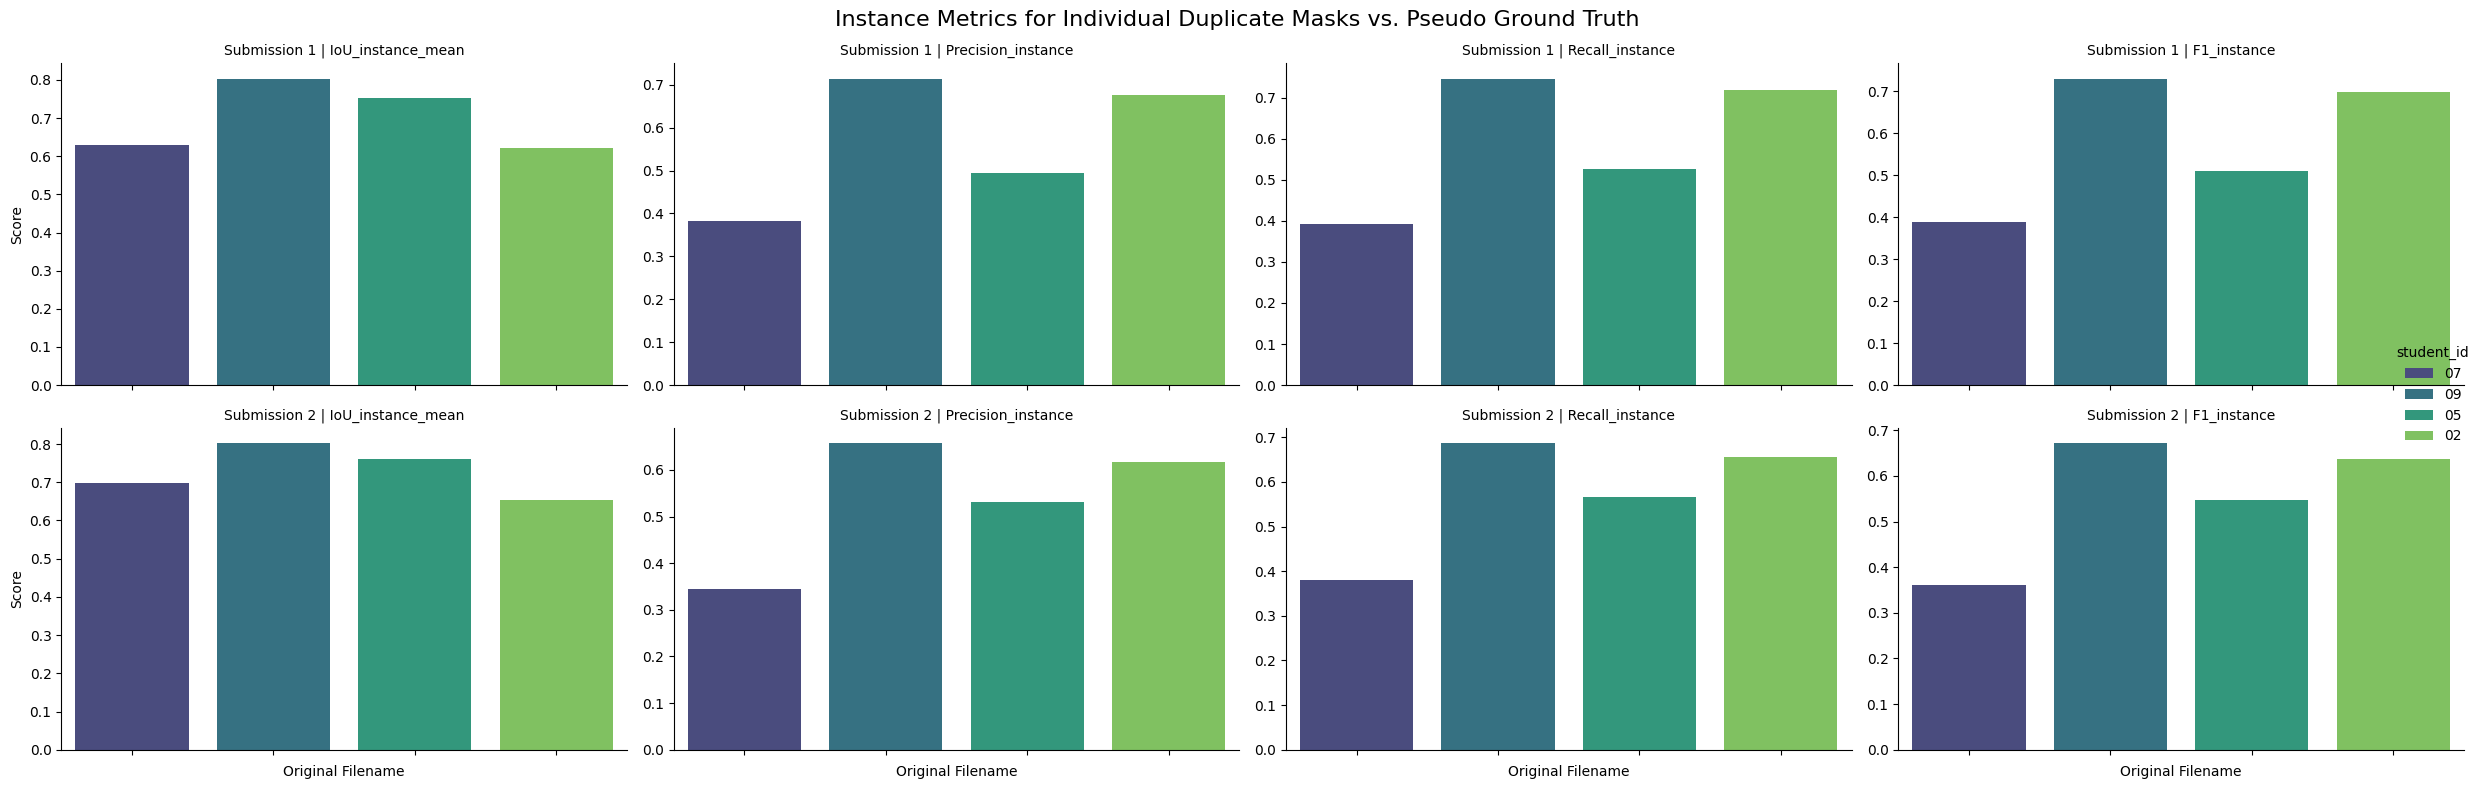

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Visualization 2: Individual Duplicate masks against Pseudo Ground Truth (Instance Metrics) ---
if not duplicate_pseudo_gt_comparison_df.empty:
    print("\n### Visualization: Individual Duplicate Masks vs. Pseudo Ground Truth (Instance Metrics)\n")
    metrics_to_plot_instance = ['IoU_instance_mean', 'Precision_instance', 'Recall_instance', 'F1_instance']
    melted_duplicate_pseudo_gt_comp_df = duplicate_pseudo_gt_comparison_df.melt(
        id_vars=['student_id', 'original_filename', 'duplicate_submission_idx'],
        value_vars=metrics_to_plot_instance,
        var_name='Metric',
        value_name='Score'
    )

    g = sns.catplot(
        data=melted_duplicate_pseudo_gt_comp_df,
        x='original_filename',
        y='Score',
        hue='student_id',
        col='Metric',
        row='duplicate_submission_idx',
        kind='bar',
        height=4, aspect=1.5,
        palette='viridis',
        legend='auto',
        legend_out=True,
        errorbar=None,
        sharey=False
    )
    g.set_axis_labels("Original Filename", "Score")
    g.set_titles(row_template="Submission {row_name}", col_template="{col_name}")
    g.set_xticklabels(rotation=45, ha='right')
    g.fig.suptitle('Instance Metrics for Individual Duplicate Masks vs. Pseudo Ground Truth', y=0.98, fontsize=16)
    plt.tight_layout()
    plt.savefig('individual_duplicate_masks_vs_pseudo_gt-instance.png')
    plt.show()
else:
    print("\nNo data available for 'Individual Duplicate Masks vs. Pseudo Ground Truth' visualization.")

Other

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Filter for calibration images from the combined dataframe
calibration_df = all_students_df[all_students_df['image_type'] == 'calibration'].copy()

# Ensure 'student_id' column exists for easier grouping/identification
if 'student_id' not in calibration_df.columns:
    calibration_df['student_id'] = calibration_df['student_folder'].str.replace('student_', '')

# Ensure 'label_map_full_path' is added, pointing to student's own masks
if 'label_map_full_path' not in calibration_df.columns:
    # FIX: Changed 'labels' to 'images' for student mask paths
    calibration_df['label_map_full_path'] = calibration_df['path'].astype(str).apply(
        lambda x: os.path.join(base_repo_path, 'labels', x).replace('.tiff', '.tif')
    )

# Add 'pseudo_gt_mask_full_path' using the specified structure for the new GT source
if 'pseudo_gt_mask_full_path' not in calibration_df.columns:
    calibration_df['pseudo_gt_mask_full_path'] = calibration_df.apply(
        lambda row: os.path.join(base_repo_path, 'labels', 'GT', row['student_folder'], row['image_name']),
        axis=1
    )
    print("Added 'pseudo_gt_mask_full_path' to calibration_df for new GT source.")


# --- Comparison: Calibration masks against pseudo ground truth mask for each student ---
print("\n--- Starting Calibration vs. Pseudo Ground Truth Comparison (Each Student Mask) ---")
calibration_pseudo_gt_comparison_results = []

for index, row in calibration_df.iterrows():
    student_mask_path = row['label_map_full_path']
    pseudo_gt_mask_path = row['pseudo_gt_mask_full_path']
    original_filename = row['original_filename']
    student_id = row['student_id']

    pseudo_gt_labels, pseudo_gt_size = load_mask_as_array(pseudo_gt_mask_path)
    if pseudo_gt_labels is None:
        print(f"Pseudo GT mask not found or failed to load for {original_filename} (student {student_id}). Skipping.")
        continue

    student_labels, _ = load_mask_as_array(student_mask_path, target_size=pseudo_gt_size) # Resize student mask to Pseudo GT size
    if student_labels is None:
        print(f"Student mask not found or failed to load for {original_filename} (student {student_id}). Skipping.")
        continue

    # Calculate instance metrics
    instance_metrics = calculate_instance_metrics(student_labels, pseudo_gt_labels)

    calibration_pseudo_gt_comparison_results.append({
        'student_id': student_id,
        'original_filename': original_filename,
        'comparison_type': 'student_calibration_vs_pseudo_gt',
        'student_mask_path': student_mask_path,
        'pseudo_gt_mask_full_path': pseudo_gt_mask_path, # ADDED THIS LINE
        **instance_metrics
    })

calibration_pseudo_gt_comparison_df = pd.DataFrame(calibration_pseudo_gt_comparison_results)


Added 'pseudo_gt_mask_full_path' to calibration_df for new GT source.

--- Starting Calibration vs. Pseudo Ground Truth Comparison (Each Student Mask) ---
Student mask not found or failed to load for 9GRAY_015-cropped (student 10). Skipping.
Student mask not found or failed to load for 1GRAY_030-cropped (student 10). Skipping.
Student mask not found or failed to load for 4GRAY_000-cropped (student 10). Skipping.
Student mask not found or failed to load for 16GRAY_045-cropped (student 10). Skipping.
Student mask not found or failed to load for 16GRAY_045-cropped (student 03). Skipping.
Student mask not found or failed to load for 1GRAY_030-cropped (student 03). Skipping.
Student mask not found or failed to load for 9GRAY_015-cropped (student 03). Skipping.
Student mask not found or failed to load for 4GRAY_000-cropped (student 03). Skipping.
Student mask not found or failed to load for 1GRAY_030-cropped (student 04). Skipping.
Student mask not found or failed to load for 9GRAY_015-cropp


Calibration vs. Pseudo Ground Truth Comparison Results:


,student_id,original_filename,comparison_type,student_mask_path,pseudo_gt_mask_full_path,IoU_instance_mean,Precision_instance,Recall_instance,F1_instance,TP_instance,FP_instance,FN_instance,submission_idx
0,07,4GRAY_000-cropped,student_calibration_vs_pseudo_gt,/content/semester-project-2026/labels/student_...,/content/semester-project-2026/labels/GT/stude...,0.576661,0.208333,0.223881,0.215827,15,57,52,1
1,07,16GRAY_045-cropped,student_calibration_vs_pseudo_gt,/content/semester-project-2026/labels/student_...,/content/semester-project-2026/labels/GT/stude...,0.645646,0.280702,0.313725,0.296296,16,41,35,1
2,07,1GRAY_030-cropped,student_calibration_vs_pseudo_gt,/content/semester-project-2026/labels/student_...,/content/semester-project-2026/labels/GT/stude...,0.688534,0.964286,0.981818,0.972973,54,2,1,1
3,07,9GRAY_015-cropped,student_calibration_vs_pseudo_gt,/content/semester-project-2026/labels/student_...,/content/semester-project-2026/labels/GT/stude...,0.659360,0.549296,0.582090,0.565217,39,32,28,1
4,09,16GRAY_045-cropped,student_calibration_vs_pseudo_gt,/content/semester-project-2026/labels/student_...,/content/semester-project-2026/labels/GT/stude...,0.776296,0.609375,0.764706,0.678261,39,25,12,1



Summary Statistics for Calibration vs. Pseudo Ground Truth Comparison (Instance):


,IoU_instance_mean,Precision_instance,Recall_instance,F1_instance
count,16.000000,16.000000,16.000000,16.000000
mean,0.719166,0.669616,0.711413,0.688716
std,0.092727,0.220140,0.210727,0.213991
min,0.576661,0.208333,0.223881,0.215827
25%,0.636492,0.564247,0.649254,0.619753
50%,0.720539,0.657073,0.735879,0.679710
75%,0.805647,0.829154,0.827205,0.830261
max,0.836519,0.964286,0.981818,0.972973



### Visualization: Individual Calibration Masks vs. Pseudo Ground Truth (Instance Metrics)



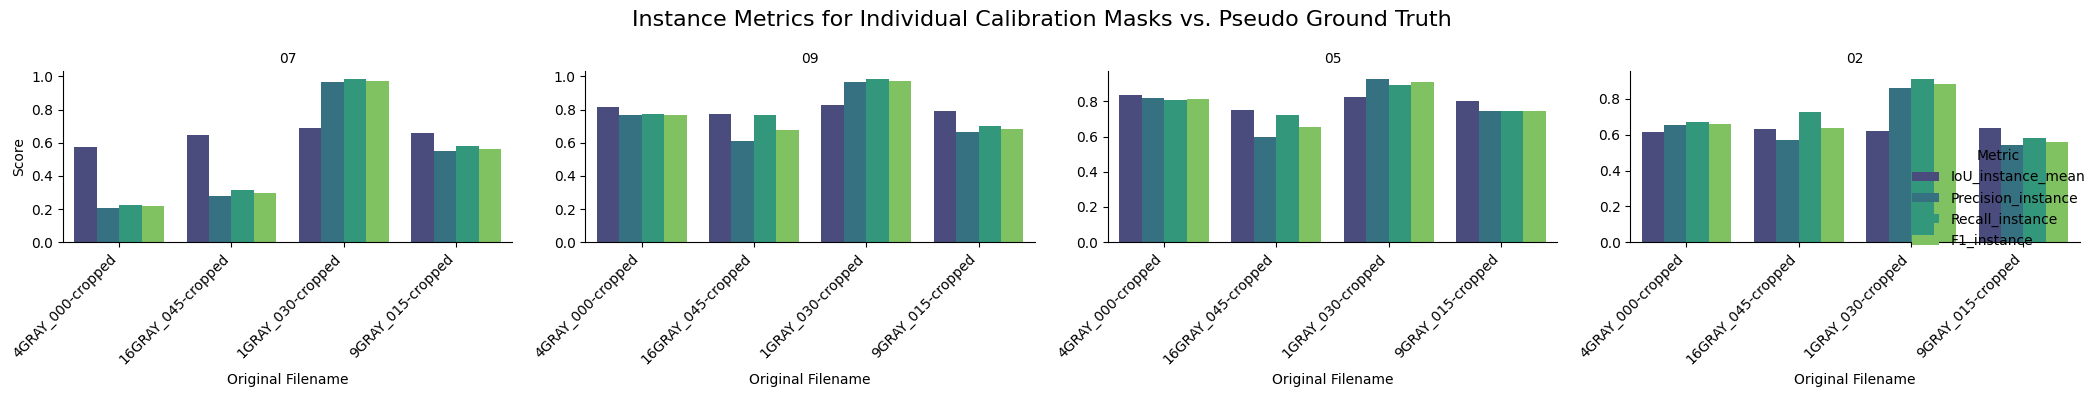

In [50]:
if not calibration_pseudo_gt_comparison_df.empty:
    # Add a column to differentiate between multiple submissions for the same image by the same student (if applicable)
    calibration_pseudo_gt_comparison_df['submission_idx'] = calibration_pseudo_gt_comparison_df.groupby(['student_id', 'original_filename']).cumcount() + 1

    print("\nCalibration vs. Pseudo Ground Truth Comparison Results:")
    display(calibration_pseudo_gt_comparison_df.head())
    print("\nSummary Statistics for Calibration vs. Pseudo Ground Truth Comparison (Instance):")
    display(calibration_pseudo_gt_comparison_df[['IoU_instance_mean', 'Precision_instance', 'Recall_instance', 'F1_instance']].describe())
else:
    print("\nNo calibration vs. pseudo ground truth comparison results generated.")


# --- Visualization 3: Individual Calibration masks against Pseudo Ground Truth (Instance Metrics) ---
if not calibration_pseudo_gt_comparison_df.empty:
    print("\n### Visualization: Individual Calibration Masks vs. Pseudo Ground Truth (Instance Metrics)\n")
    metrics_to_plot_instance = ['IoU_instance_mean', 'Precision_instance', 'Recall_instance', 'F1_instance']
    melted_calibration_pseudo_gt_comp_df = calibration_pseudo_gt_comparison_df.melt(
        id_vars=['student_id', 'original_filename', 'submission_idx'],
        value_vars=metrics_to_plot_instance,
        var_name='Metric',
        value_name='Score'
    )

    # Create a combined 'student_submission' column for faceting
    melted_calibration_pseudo_gt_comp_df['student_submission'] = \
        'S' + melted_calibration_pseudo_gt_comp_df['student_id'].astype(str) + \
        '_Sub' + melted_calibration_pseudo_gt_comp_df['submission_idx'].astype(str)

    melted_calibration_pseudo_gt_comp_df.to_csv('calibration_pseudo_gt_comparison_df.csv', index=False)

    g = sns.catplot(
        data=melted_calibration_pseudo_gt_comp_df,
        x='original_filename',
        y='Score',
        hue='Metric',
        col='student_id', # Use combined student and submission for columns
        kind='bar',
        col_wrap=4, # Adjust col_wrap to fit more plots per row if needed
        height=4, aspect=1.2, # Adjusted aspect
        palette='viridis',
        legend='auto',
        legend_out=True,
        errorbar=None,
        sharey=False
    )
    g.set_axis_labels("Original Filename", "Score")
    g.set_titles(col_template="{col_name}") # Set title for combined column
    g.set_xticklabels(rotation=45, ha='right')
    g.fig.suptitle('Instance Metrics for Individual Calibration Masks vs. Pseudo Ground Truth', y=0.98, fontsize=16)
    #plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent suptitle overlap
    plt.tight_layout()
    plt.savefig('individual_calibration_masks_vs_pseudo_gt-instance.png')
    plt.show()
else:
    print("\nNo data available for 'Individual Calibration Masks vs. Pseudo Ground Truth' visualization.")

pseudo GT counts

In [51]:
import pandas as pd
import numpy as np
import os
from PIL import Image
from skimage.measure import label

# Ensure 'base_repo_path' is defined, if not already from previous cells
if 'base_repo_path' not in locals():
    base_repo_path = '/content/semester-project-2026/'

# Add 'student_id' column to all_students_df if it doesn't exist
if 'student_id' not in all_students_df.columns:
    all_students_df['student_id'] = all_students_df['student_folder'].str.replace('student_', '')

# Add 'pseudo_gt_mask_full_path' to all_students_df if it doesn't exist
# This path points to the GT masks that match the student's folder structure.
if 'pseudo_gt_mask_full_path' not in all_students_df.columns:
    all_students_df['pseudo_gt_mask_full_path'] = all_students_df.apply(
        lambda row: os.path.join(base_repo_path, 'labels', 'GT', row['student_folder'], row['image_name']),
        axis=1
    )


pseudo_gt_counts_results = []

# Iterate over each row of the all_students_df
for index, row in all_students_df.iterrows():
    student_id = row['student_id']
    original_filename = row['original_filename']
    image_name = row['image_name']
    pseudo_gt_mask_path = row['pseudo_gt_mask_full_path']

    # Load the pseudo GT mask using the helper function defined earlier
    pseudo_gt_labels, _ = load_mask_as_array(pseudo_gt_mask_path)

    pGT_count = 0
    if pseudo_gt_labels is not None:
        # Convert to binary mask (non-zero pixels are foreground)
        binary_mask = pseudo_gt_labels > 0
        # Label connected components
        labeled_array = label(binary_mask)
        # The number of objects is the maximum label value (since label assigns 1, 2, ... for objects)
        pGT_count = labeled_array.max()

    pseudo_gt_counts_results.append({
        'student_id': student_id,
        'original_filename': original_filename,
        'image_name': image_name,
        'pGT_count': pGT_count
    })

# Create the DataFrame
pseudo_gt_counts_df = pd.DataFrame(pseudo_gt_counts_results)

# Display the head of the new DataFrame
print("Pseudo GT Object Counts:")
display(pseudo_gt_counts_df.head())

Pseudo GT Object Counts:


,student_id,original_filename,image_name,pGT_count
0,10,19GRAY_015-cropped,img_1.tif,55
1,10,14GRAY_000-cropped,img_2.tif,77
2,10,18GRAY_030-cropped,img_3.tif,43
3,10,11GRAY_030-cropped,img_4.tif,41
4,10,10GRAY_030-cropped,img_5.tif,54


In [52]:
pseudo_gt_counts_df.to_csv('pseudo_gt_counts.csv', index=False)